In [1]:
_#Import libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import(
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [3]:
#Specify the file driectory
df = pd.read_csv("/content/drive/MyDrive/auto_mpg_synthetic_dataset.csv")

## **Exercise 1: Load and Explore**

In [ ]:
#Display head
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,25.6,4,240.8,144,2832,18.2,72,1,Car_001
1,34.4,8,411.6,140,2344,15.9,79,1,Car_002
2,12.9,6,392.2,210,4301,14.5,76,3,Car_003
3,19.9,5,322.4,170,3244,16.9,76,1,Car_004
4,39.9,4,253.9,79,1500,17.4,70,1,Car_005


In [ ]:
#row and columns
df.shape

(300, 9)

In [ ]:
#Check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           300 non-null    float64
 1   cylinders     300 non-null    int64  
 2   displacement  300 non-null    float64
 3   horsepower    300 non-null    int64  
 4   weight        300 non-null    int64  
 5   acceleration  300 non-null    float64
 6   model_year    300 non-null    int64  
 7   origin        300 non-null    int64  
 8   car_name      300 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 21.2+ KB


In [ ]:
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.0000,300.000000
mean,27.211000,5.196667,316.861333,153.580000,2796.476667,15.067667,76.0500,1.836667
std,7.564451,1.494020,73.708896,32.989969,678.251591,2.039490,3.5782,0.867466
min,8.000000,3.000000,158.100000,79.000000,1500.000000,9.800000,70.0000,1.000000
25%,21.500000,4.000000,258.975000,129.750000,2291.750000,13.600000,73.0000,1.000000
50%,27.850000,4.000000,295.750000,153.500000,2789.000000,15.100000,76.0000,2.000000
75%,32.425000,6.000000,362.350000,175.000000,3244.750000,16.400000,79.0000,3.000000
max,46.600000,8.000000,500.000000,239.000000,4955.000000,20.200000,82.0000,3.000000


Questions
1. How many observations are in the dataset?
* 300
2. Which column is the target variable?
* mpg
3. Which column contains text?
* car name

## **Exercise 2: Missing Values**

In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


Questions
1. Which columns contain missing values?
* No column
2. Why should missing values be handled before training?
* To prevent model bias
* To improve accuracy
* Difficult to do matimatical operation on NaN value

## **Exercise 3: Exploratory Data Analysis**

Text(0, 0.5, 'Frequency (Count of Cars)')

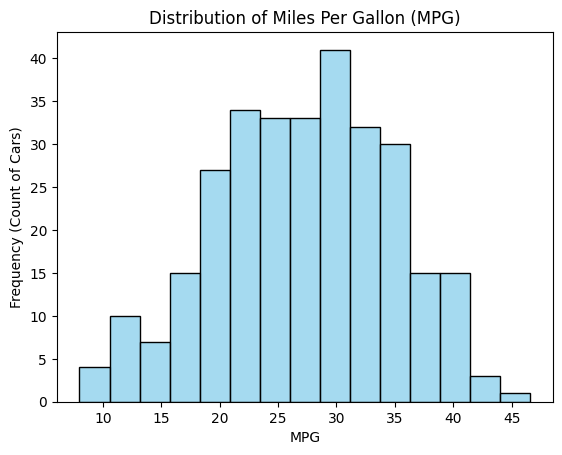

In [ ]:
#Histogram of MPG
sns.histplot(data=df, x='mpg', bins=15, color='skyblue')
plt.title('Distribution of Miles Per Gallon (MPG)')
plt.xlabel('MPG')
plt.ylabel('Frequency (Count of Cars)')

Text(0.5, 0, 'MPG')

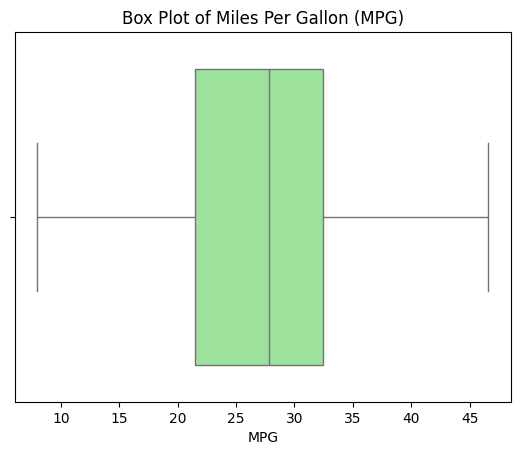

In [ ]:
#Box plot of MPG
sns.boxplot(data=df, x='mpg', color='lightgreen')
plt.title('Box Plot of Miles Per Gallon (MPG)')
plt.xlabel('MPG')

In [ ]:
#Correlation matrix
numeric_columns = df.select_dtypes(include=[np.number]).columns
correlations = (
df[numeric_columns]
.corr()["mpg"]
.sort_values(ascending=False)
)
correlations

,mpg
mpg,1.000000
origin,0.116329
model_year,0.101659
acceleration,0.043016
cylinders,-0.069677
displacement,-0.290129
horsepower,-0.824688
weight,-0.927553


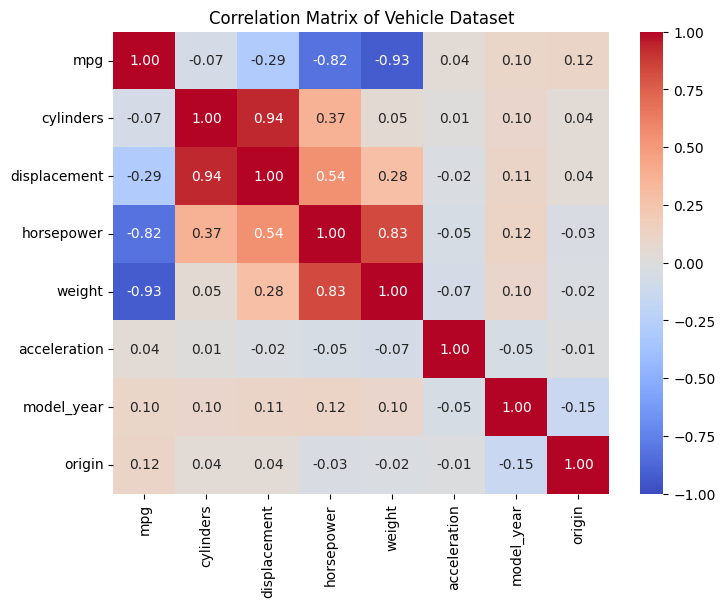

In [ ]:
numeric_df = df.drop(columns=['car_name'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Vehicle Dataset')
plt.show()

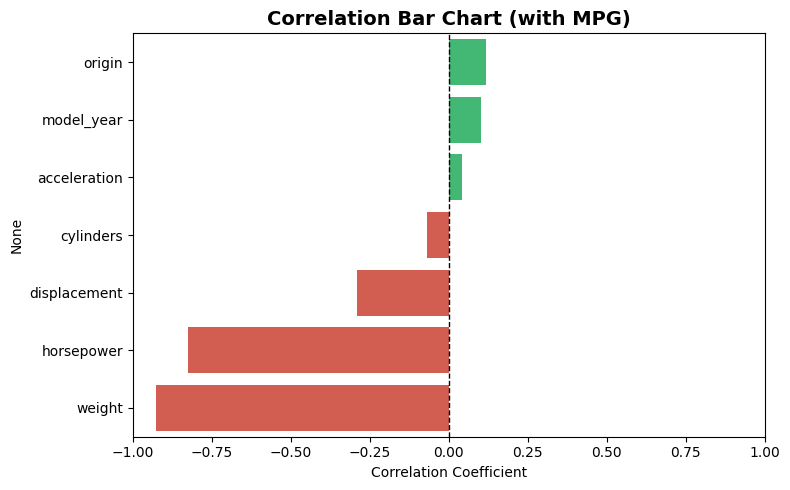

In [ ]:
# Bar Chart (sorted, excluding self-correlation)

fig, ax = plt.subplots(figsize=(8, 5))
mpg_corr = corr_matrix["mpg"].drop("mpg").sort_values(ascending=False)
colors = ["#2ecc71" if val >= 0 else "#e74c3c" for val in mpg_corr.values]
sns.barplot(
    x=mpg_corr.values, y=mpg_corr.index, palette=colors, hue=mpg_corr.index, ax=ax
)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Correlation Bar Chart (with MPG)", fontsize=14, fontweight="bold")
ax.set_xlabel("Correlation Coefficient")
ax.set_xlim(-1, 1)

plt.tight_layout()


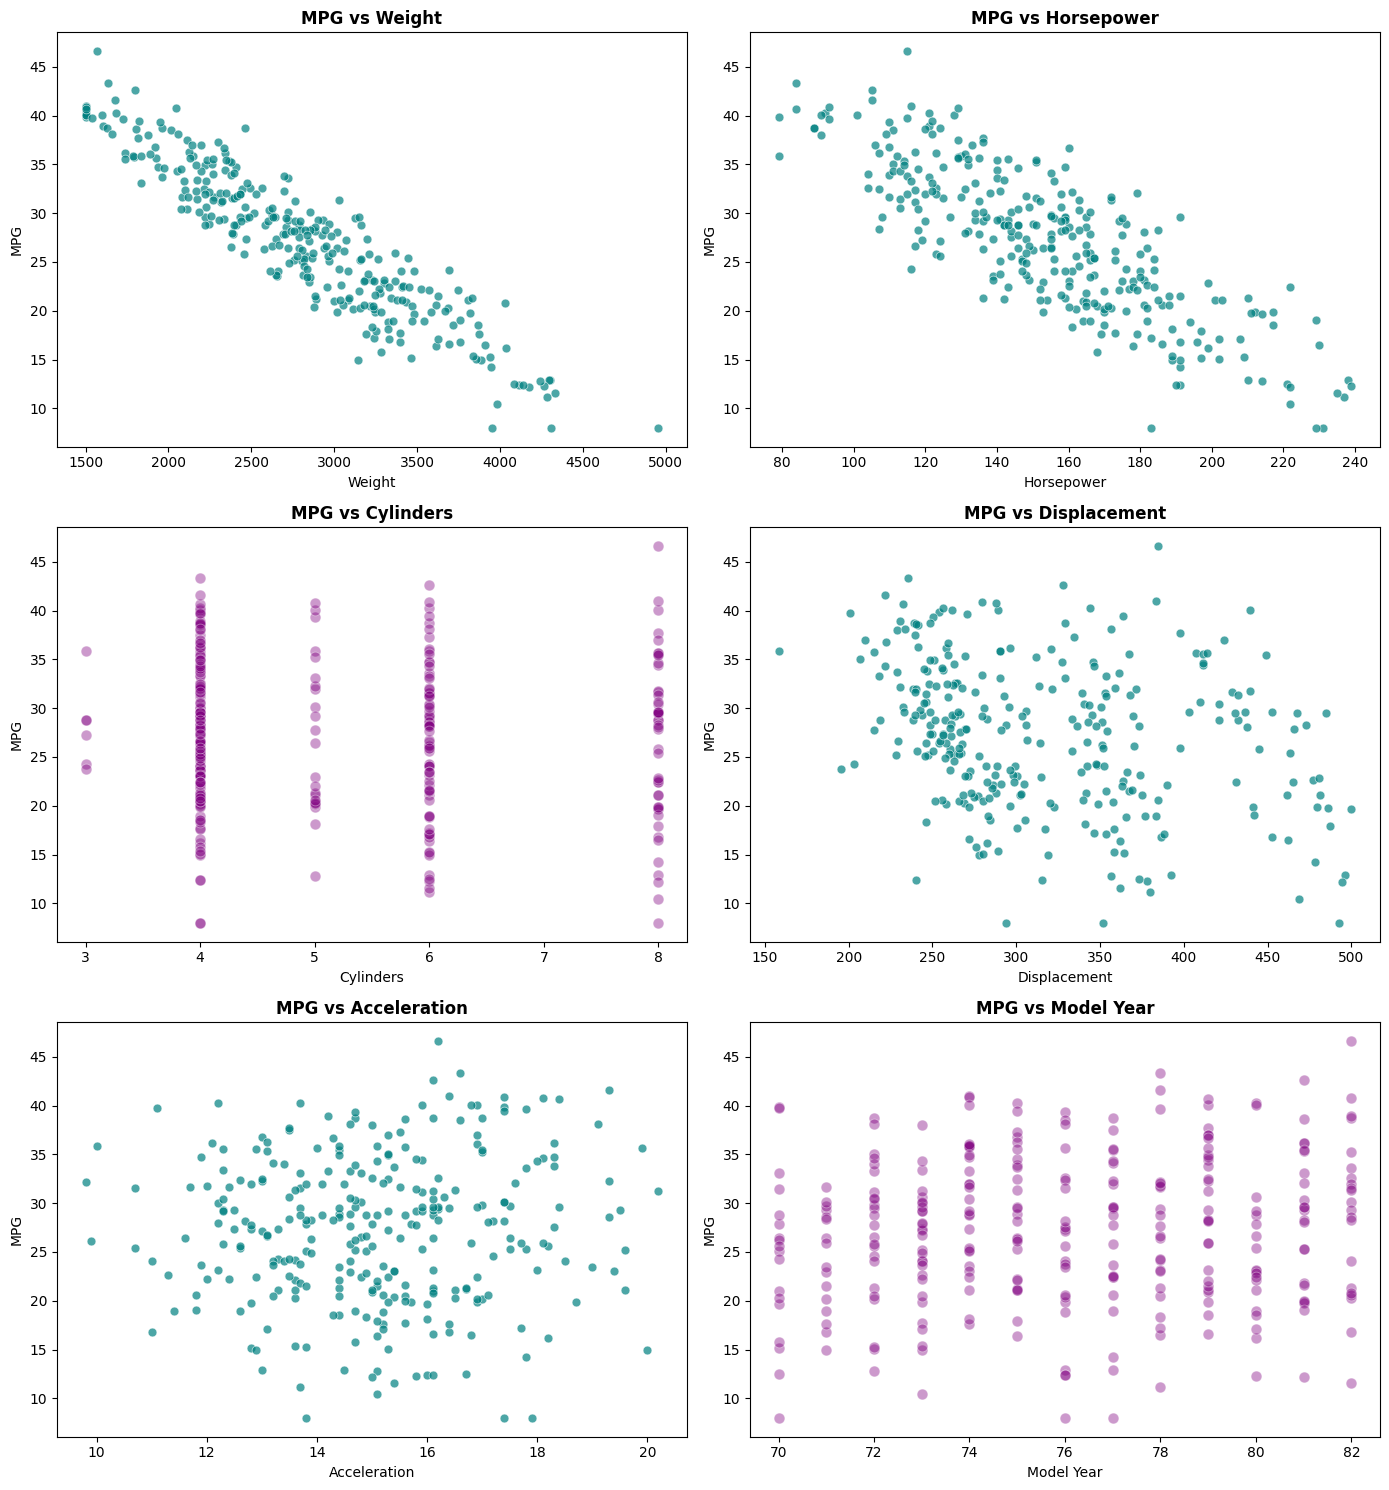

In [ ]:
# Scatter plot
scatter_features = [
    "weight",
    "horsepower",
    "cylinders",
    "displacement",
    "acceleration",
    "model_year",
]
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()  # Flatten the 2D array to loop easily

for i, feature in enumerate(scatter_features):
    if feature in ["cylinders", "model_year"]:
        sns.scatterplot(
            data=df,
            x=feature,
            y="mpg",
            alpha=0.4,
            color="purple",
            s=60,
            ax=axes[i],
        )
    else:
        sns.scatterplot(
            data=df, x=feature, y="mpg", alpha=0.7, color="teal", s=40, ax=axes[i]
        )

    axes[i].set_title(
        f"MPG vs {feature.replace('_', ' ').title()}",
        fontsize=12,
        fontweight="bold",
    )
    axes[i].set_ylabel("MPG")
    axes[i].set_xlabel(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

In [4]:
#Further check on the outliner
numeric_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    print(outliers[[col]].head())


mpg
Lower bound: 5.11
Upper bound: 48.81
Number of outliers: 0
Empty DataFrame
Columns: [mpg]
Index: []

displacement
Lower bound: 103.91
Upper bound: 517.41
Number of outliers: 0
Empty DataFrame
Columns: [displacement]
Index: []

horsepower
Lower bound: 61.88
Upper bound: 242.88
Number of outliers: 0
Empty DataFrame
Columns: [horsepower]
Index: []

weight
Lower bound: 862.25
Upper bound: 4674.25
Number of outliers: 1
     weight
246    4955

acceleration
Lower bound: 9.40
Upper bound: 20.60
Number of outliers: 0
Empty DataFrame
Columns: [acceleration]
Index: []


Question

**MPG VS Weight**

Is the relationship positive or negative?
* Negative

Is it strong or weak?
* Strong

Are there any outliers?
* Yes around 4955

**MPG VS Horsepower**

Is the relationship positive or negative?
* Negative

Is it strong or weak?
* Strong

Are there any outliers?
* No

**MPG VS Cylinder**

Is the relationship positive or negative?
* Negative

Is it strong or weak?
* Moderate

Are there any outliers?
* No

**MPG VS Displacment**

Is the relationship positive or negative?
* Negative

Is it strong or weak?
* Moderate

Are there any outliers?
* No

**MPG VS Acceleration**

Is the relationship positive or negative?
* Positive

Is it strong or weak?
* Weak

Are there any outliers?
* No

**MPG VS Model Year**

Is the relationship positive or negative?
*  Positive

Is it strong or weak?
* Moderate

Are there any outliers?
* No
